In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from define_variables import get_hmc_config
import arviz as az
from scipy.stats import norm
import imageio.v2 as imageio
from scipy.stats import gaussian_kde
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors
from matplotlib.colors import Normalize

In [2]:
config, config_str = get_hmc_config()

In [5]:
samples = np.load(f"../../../../output/2d_example_unified/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/2d_example_unified/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/2d_example_unified/bias_values_{config_str}.npy")
delF = np.load(f"../../../../output/2d_example_unified/delF_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/2d_example_unified/resampsamp_{config_str}.npy")

In [6]:
def energy_function(variables):
    return 1.34549*variables[0]**4 + 1.90211*variables[0]**3*variables[1]+ 3.92705*variables[0]**2*variables[1]**2-6.44246*variables[0]**2- 1.90211*variables[0]*variables[1]**3+5.58721*variables[0]*variables[1] + 1.33481*variables[0] + 1.34549*variables[1]**4- 5.55754*variables[1]**2+0.904586*variables[1] + 18.5598

In [7]:
x = np.linspace(-3, 3, 1000)
y = np.linspace(-3, 3, 1000)
dx, dy = x[1]-x[0], y[1]-y[0]
X, Y = np.meshgrid(x, y, indexing="xy")

U = energy_function([X, Y])

P = np.exp(-U)
P/=np.sum(P)*dx*dy
true_marginal_likelihood = np.sum(P, axis = 0) * dy
free_energy = -np.log(true_marginal_likelihood)
free_energy-= np.min(free_energy)

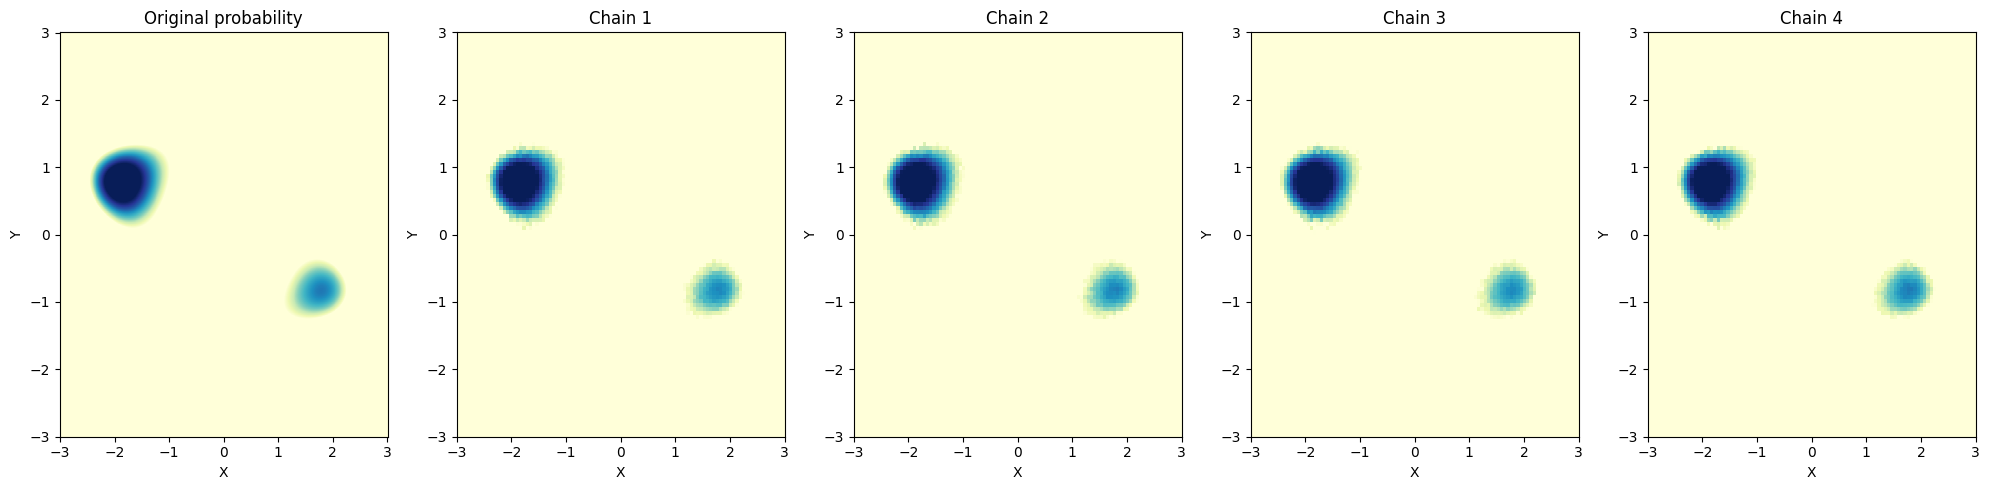

In [8]:
fig, axs= plt.subplots(1, config["num_chains"] + 1, figsize=(5*config["num_chains"], 5))
norm = colors.Normalize(vmin=P.min(), vmax=P.max())

axs[0].pcolormesh(X, Y, -np.log(P), cmap="YlGnBu_r", norm = norm, shading = "auto")
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_title(f"Original probability")

for i in range(1, config["num_chains"] + 1):
    # Compute a 2D histogram and normalize to get a probability density
    hist, xedges, yedges = np.histogram2d(
        resampled_samples[i-1, :, 0], resampled_samples[i-1, :, 1],
        bins=100, range=[[-3, 3], [-3, 3]], density=True
    )

    # Grid centers
    xpos = (xedges[:-1] + xedges[1:]) / 2
    ypos = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xpos, ypos, indexing='ij')

    # Plot as a 2D color map
    cmap = cm.YlGnBu_r
    norm = colors.Normalize(vmin=hist.min(), vmax=hist.max())
    pcm = axs[i].pcolormesh(X, Y, -np.log(hist + 1e-12), cmap=cmap, norm=norm, shading='auto')

    axs[i].set_xlabel("X")
    axs[i].set_ylabel("Y")
    axs[i].set_title(f"Chain {i}")

plt.tight_layout()
plt.show()

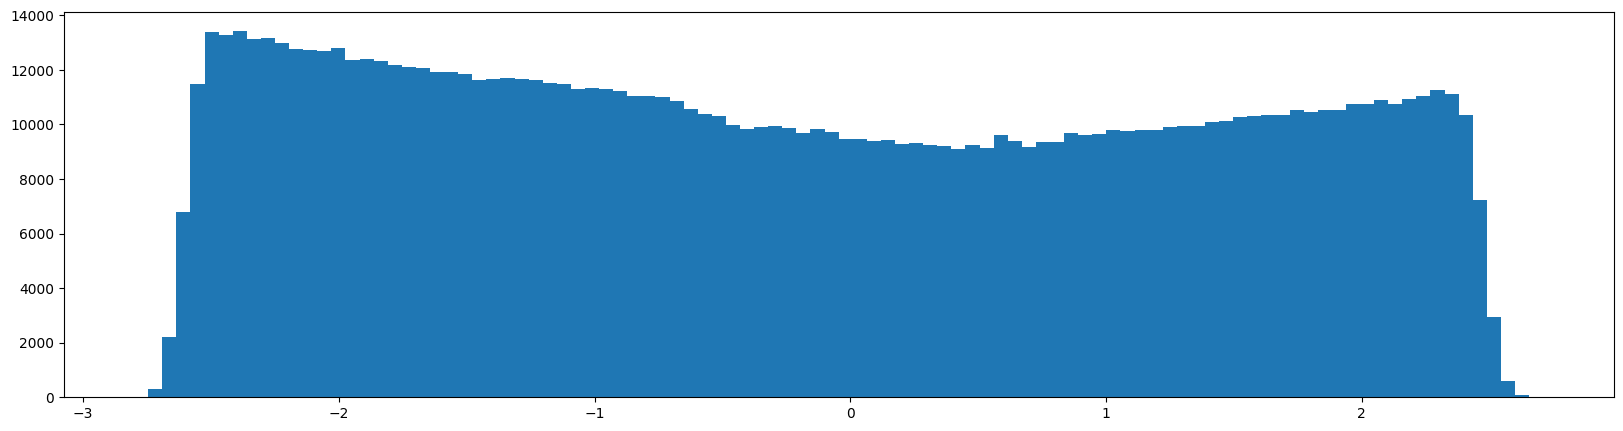

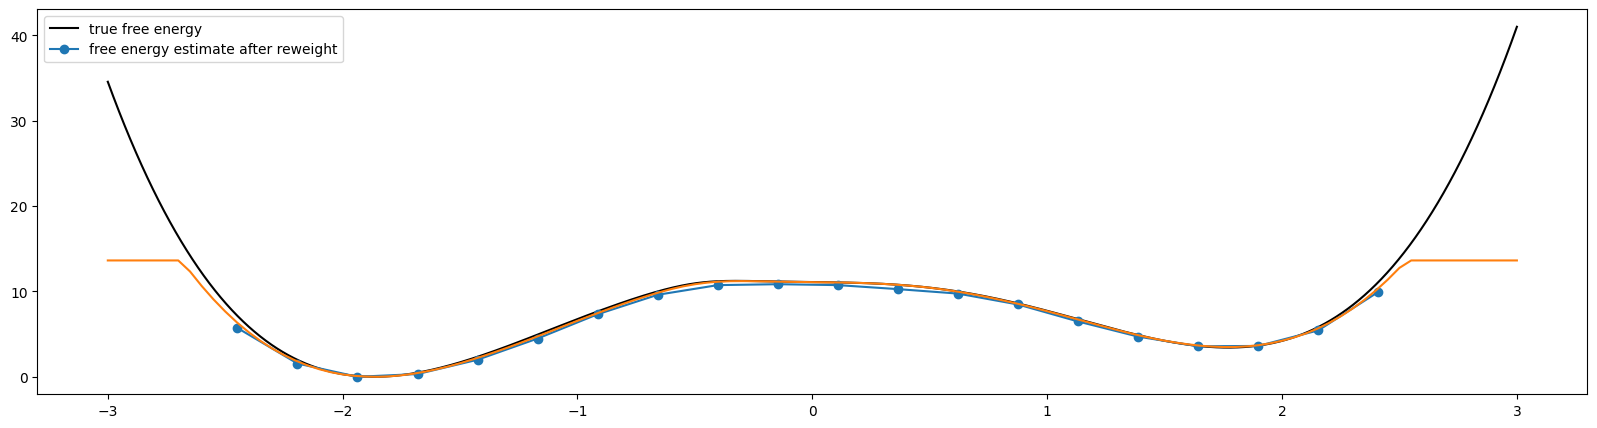

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
# plt.plot(valid_samples[0,:,0])
plt.hist(samples[0,:,0], bins = 100)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
counts, bin_edges = np.histogram(resampled_samples[0,:, 0], bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
counts[counts == 0] = 1e-12  
free_energy_est_reweight = -np.log(counts)
free_energy_est_reweight-= np.min(free_energy_est_reweight)
ax.plot(x, free_energy, color="black", label=f"true free energy")
ax.plot(bin_centers, free_energy_est_reweight, '-o', label="free energy estimate after reweight")
ax.plot(np.linspace(-3, 3, config["num_lambda"]), delF[0, -1, :] - np.min(delF[0, -1, :]))
plt.legend()
plt.show()

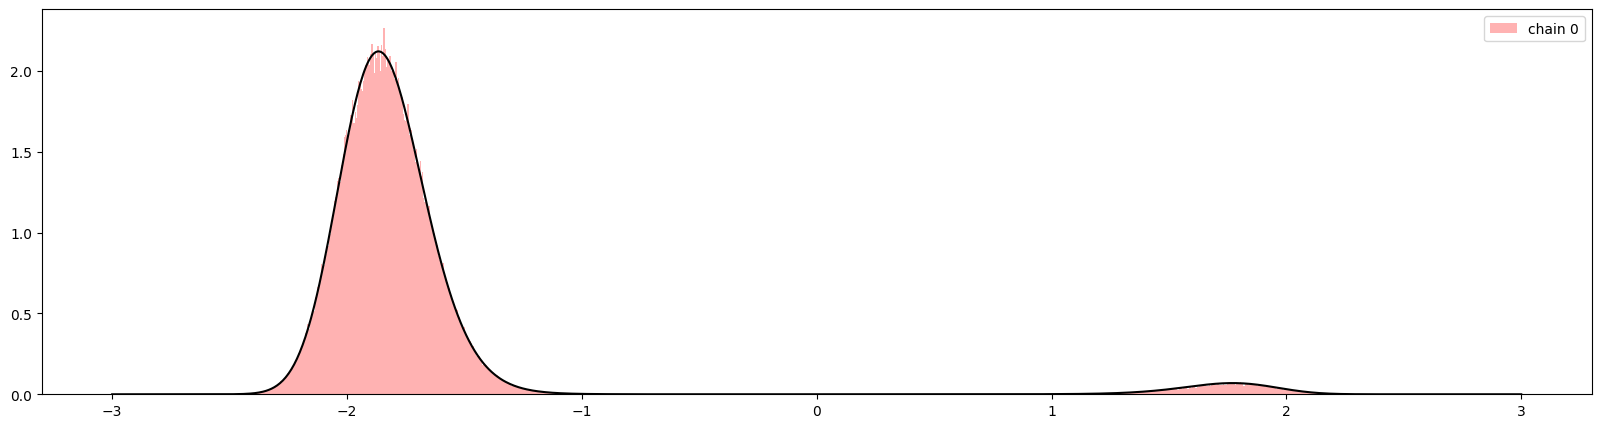

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
ax.hist(resampled_samples[0, :, 0], bins=1000, color="red", density=True, alpha=0.3, label=f"chain {0}")
ax.legend()
ax.plot(x, true_marginal_likelihood, color="black")
plt.show()